In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.dataset_loader import load_detection_dataset, load_figshare_dataset
from src.model import build_detection_model, compile_detection_model
from src.model import build_classification_model, compile_classification_model

In [2]:
detection_path = "../data/tumor_detection_dataset"
figshare_path = "../data/figshare_dataset/brainTumorDataPublic_1-766"

X_det, y_det = load_detection_dataset(detection_path)
X_type, y_type = load_figshare_dataset(figshare_path)



Detection Dataset Shape: (253, 224, 224, 3)
Classification Dataset Shape: (766, 224, 224, 1)


In [3]:
from sklearn.model_selection import train_test_split

X_train_det, X_test_det, y_train_det, y_test_det = train_test_split(
    X_det, y_det, test_size=0.3, random_state=42,
    stratify=y_det 
)

X_train_type, X_test_type, y_train_type, y_test_type = train_test_split(
    X_type, y_type, test_size=0.3, random_state=42
)

In [4]:
import numpy as np

print(np.unique(y_train_det, return_counts=True))
print(np.unique(y_test_det, return_counts=True))

(array([0, 1]), array([ 69, 108]))
(array([0, 1]), array([29, 47]))


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=3,
    zoom_range=0.03,
    
)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [8]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [9]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,   # less aggressive
    patience=7,
    min_lr=1e-6
)

In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_det),
    y=y_train_det
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.2826086956521738), 1: np.float64(0.8194444444444444)}


In [11]:
# from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# X_train_det = preprocess_input(X_train_det)
# X_test_det  = preprocess_input(X_test_det)

In [12]:
model_det = build_detection_model()
model_det = compile_detection_model(model_det)

history_det = model_det.fit(
    datagen.flow(X_train_det, y_train_det, batch_size=8),
    epochs=20,
    validation_data=(X_test_det, y_test_det),
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights
)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 614ms/step - accuracy: 0.5028 - loss: 0.9811 - val_accuracy: 0.7368 - val_loss: 0.6173 - learning_rate: 1.0000e-04
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 411ms/step - accuracy: 0.6723 - loss: 0.6948 - val_accuracy: 0.7763 - val_loss: 0.5476 - learning_rate: 1.0000e-04
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 449ms/step - accuracy: 0.6780 - loss: 0.6511 - val_accuracy: 0.7632 - val_loss: 0.4976 - learning_rate: 1.0000e-04
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 414ms/step - accuracy: 0.7401 - loss: 0.5152 - val_accuracy: 0.7632 - val_loss: 0.4646 - learning_rate: 1.0000e-04
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 409ms/step - accuracy: 0.7910 - loss: 0.4427 - val_accuracy: 0.7763 - val_loss: 0.4435 - learning_rate: 1.0000e-04
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 410ms/step - accuracy: 0.7345 - loss: 0.4801 - val_accuracy: 0.8026 - val_loss: 0.4069 - learning_rate: 1.0000e-04
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 414ms/step - ac

In [13]:
loss, acc = model_det.evaluate(X_test_det, y_test_det)
print("Test Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 573ms/step - accuracy: 0.8289 - loss: 0.3238
Test Accuracy: 0.8289473652839661


In [14]:
model_type = build_classification_model()
model_type = compile_classification_model(model_type)

history_type = model_type.fit(
    X_train_type, y_train_type,
    batch_size=8,
    epochs=30,
    validation_data=(X_test_type, y_test_type),
    callbacks=[early_stop, lr_scheduler]
)

c:\Users\Abhin\Desktop\Brain_Tumor_Minor_Project\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 60s 811ms/step - accuracy: 0.4104 - loss: 1.5003 - val_accuracy: 0.9130 - val_loss: 0.4292 - learning_rate: 1.0000e-04
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 54s 813ms/step - accuracy: 0.4534 - loss: 1.2783 - val_accuracy: 0.9130 - val_loss: 0.4050 - learning_rate: 1.0000e-04
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 54s 807ms/step - accuracy: 0.5075 - loss: 1.1119 - val_accuracy: 0.9130 - val_loss: 0.3621 - learning_rate: 1.0000e-04
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 55s 824ms/step - accuracy: 0.5429 - loss: 1.1132 - val_accuracy: 0.9261 - val_loss: 0.4094 - learning_rate: 1.0000e-04
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1801s 27s/step - accuracy: 0.5504 - loss: 1.0055 - val_accuracy: 0.9348 - val_loss: 0.4344 - learning_rate: 1.0000e-04


In [15]:
print("Detection Model Accuracy:")
model_det.evaluate(X_test_det, y_test_det)

print("Tumor Type Model Accuracy:")
model_type.evaluate(X_test_type, y_test_type)


Detection Model Accuracy:
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 670ms/step - accuracy: 0.8289 - loss: 0.3238
Tumor Type Model Accuracy:
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 470ms/step - accuracy: 0.9130 - loss: 0.4292


[0.42920032143592834, 0.9130434989929199]

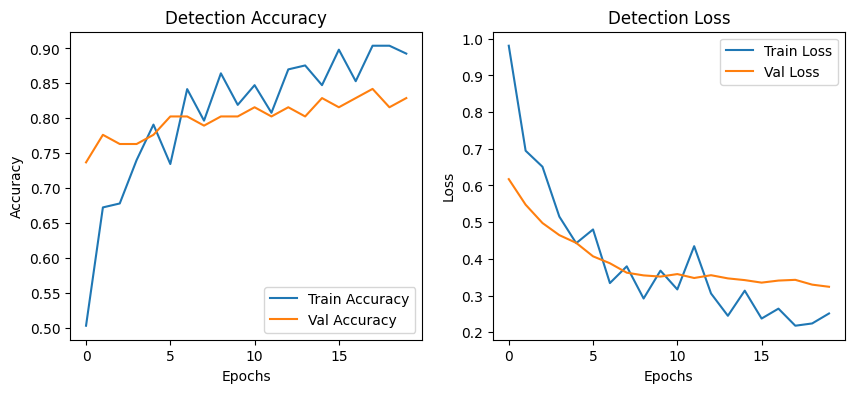

In [19]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history_det.history['accuracy'], label='Train Accuracy')
plt.plot(history_det.history['val_accuracy'], label='Val Accuracy')
plt.title("Detection Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history_det.history['loss'], label='Train Loss')
plt.plot(history_det.history['val_loss'], label='Val Loss')
plt.title("Detection Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [17]:
# model_det.save("../models/tumor_detection_model.keras")
# model_type.save("../models/tumor_type_model.keras")

In [20]:
model_det.save("../models/tumor_detection_model.keras")
model_type.save("../models/tumor_type_model.keras")